# **Insurance regression**

---

prediction-project

---

## Project Overview
  The goal of this project is to predict charges of health insurance using different characteristics (age, sex, bmi, children,smoker, region).

  This is a supervised machine learning regression task based on the Medical Cost Personal Dataset.

## Objectives


*   Perform exploratory data analysis (EDA)

*   Handle missing values and outliers

*   Engineer meaningful features
*   Create and compare multiple regresiion models


*    Evaluate model performance using RMSE


*   Interpret vital features affecting health insurance



## Business understanding

Accurate prediction of health insurance can help:


*   Real insurance agencies estimate property value
*   Individuals who are in search of a bargain prices of insurance


*   Sallers set competitive prices
*   Investors analyze market opportunities

The target variable is:
- `charges`










In [69]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
# Metrics
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 0

## Dataset Loading

In this section, the dataset "insurance.csv" is loaded and  its basic structure is inspected.

In [70]:
df=pd.read_csv('insurance.csv')
print(df.shape)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Initial Data Inspection

 Examined:
- dataset dimensions
- feature types
- missing values
- encoding
- summary statistics

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [72]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [73]:
df.shape

(1338, 7)

In [74]:
missing=df.isnull().sum().sort_values(ascending=False)
missing.head(20)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

This above shows that the dataset doesn't contain any missing values.

Next step is to change string type columns (`sex`,`smoker`,`region`) to numeric one using OneHotEncoder.


In [75]:
target_columns=['sex','smoker','region']
encoder=ColumnTransformer(
    transformers=[('one_hot',OneHotEncoder(sparse_output=False),target_columns)], remainder='passthrough'
)
encoded_df=encoder.fit_transform(df)
new_columns=encoder.get_feature_names_out()
df_final=pd.DataFrame(encoded_df,columns=new_columns)
df_final.head()

,one_hot__sex_female,one_hot__sex_male,one_hot__smoker_no,one_hot__smoker_yes,one_hot__region_northeast,one_hot__region_northwest,one_hot__region_southeast,one_hot__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__charges
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,19.0,27.900,0.0,16884.92400
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,1725.55230
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,4449.46200
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,21984.47061
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,3866.85520


To understand the most vital features, it is of utmost importance to check correlation between them.

In [76]:
df_final.corr()['remainder__charges']

one_hot__sex_female         -0.057292
one_hot__sex_male            0.057292
one_hot__smoker_no          -0.787251
one_hot__smoker_yes          0.787251
one_hot__region_northeast    0.006349
one_hot__region_northwest   -0.039905
one_hot__region_southeast    0.073982
one_hot__region_southwest   -0.043210
remainder__age               0.299008
remainder__bmi               0.198341
remainder__children          0.067998
remainder__charges           1.000000
Name: remainder__charges, dtype: float64

The Series below shows that features like `one_hot_smoker_no`\ `one_hot_smoker_yes` have the highest correlation index. Also, `remainder_age` and `remainder_bmi` should have a more complex research.

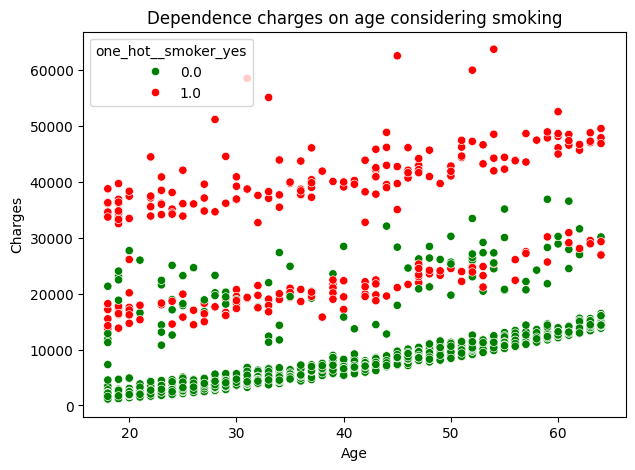

In [77]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_final, x='remainder__age', y='remainder__charges', hue='one_hot__smoker_yes',
              palette={0:'green',1:'red'})

plt.title('Dependence charges on age considering smoking')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

This plot above shows with age the amount of charges are mostly growing. Also, it is essential to add that people who smoke yend to pay higher charges. To conclude, these features (as correlation showed and the plot as well) are of utmost importance.

Next, it is quiet tempting to notice the relation between number of children and charges of the individual.

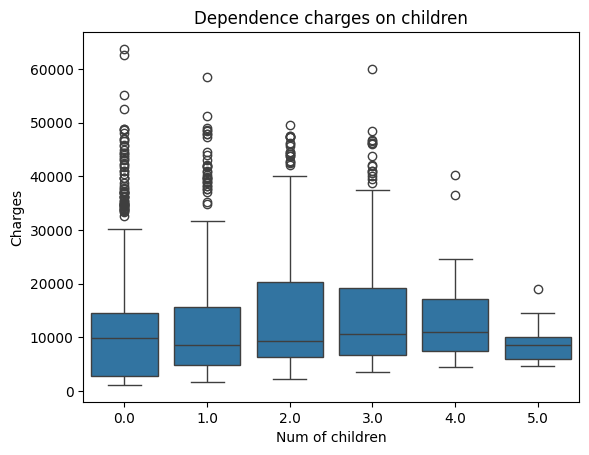

In [78]:
sns.boxplot(x='remainder__children',y='remainder__charges',data=df_final)
plt.title('Dependence charges on children')
plt.xlabel('Num of children')
plt.ylabel('Charges')
plt.show()

The plot above shows peculiar statistics due to the fact that individuals who have 3 and more children tend to pay less for health insurance.

After that, the relation between `remainder__bmi` and `remainder__charges` should be checked to notice whether individuals with higher or lower bmi tend to pay more.

<Figure size 800x500 with 0 Axes>

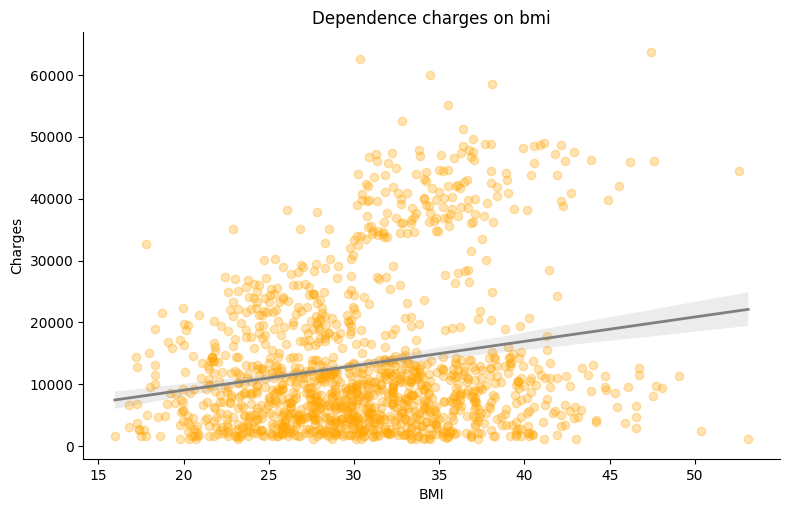

In [79]:
plt.figure(figsize=(8,5))
sns.lmplot(data=df_final, x='remainder__bmi', y='remainder__charges',
           scatter_kws={'alpha':0.3, 'color':'orange'},
           line_kws={'color':'gray','linewidth':2},
           height=5, aspect=1.6)
plt.title('Dependence charges on bmi')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

This above shows that people with higher bmi tend to pay more. 

Some health insurance prices tend to be extremely high or low (the following plot will show it). That is why it is needed to checked skewness of the `remainder__charges` and apply log_transform (in the next section) to make the data more clear for predictions and small charges will not be missed.

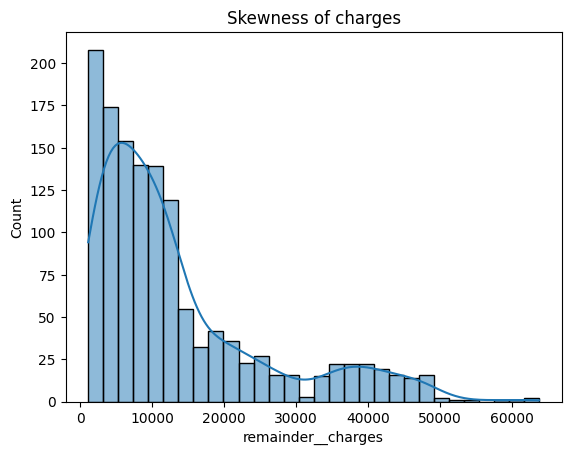

In [80]:
sns.histplot(df_final["remainder__charges"], kde=True)
plt.title('Skewness of charges')
plt.show()

In [81]:
df_final["remainder__charges"].skew()


np.float64(1.5158796580240388)

## Train-validation split:
Train-Validation Split for training and checking our future models.

In [82]:
X = df.drop("charges", axis=1)

y = np.log1p(df["charges"])

In [83]:
X_train,X_valid,y_train,y_valid=train_test_split(X,y, test_size=0.2,random_state=RANDOM_STATE)

After using `df_final` for EDA analysis, to prevent data from leakage I will apply imputer to the data.

In [96]:
categorical_cols = ['sex', 'smoker', 'region']
numerical_cols = ['age', 'bmi', 'children']
numerical_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

## Evaluation Metric

The model was evaluated using Mean Absolute Percentage Error (MAPE) and Root Mean Squared Error (RMSE).

MAPE (Mean Absolute Percentage Error) measures the average magnitude of prediction errors as a percentage of actual values. Talking about MAPE, itsexpressing error as a percentage is universally understood by business stakeholders without requiring domain-specific context about absolute scales.
Limitation: MAPE is undefined or unstable when actual values are zero or near-zero. In such cases, alternative metrics (sMAPE, WAPE) should be used.


RMSE measures the average magnitude of prediction errors and penalizes large errors more heavily due to squaring.This metric is particularly suitable for house price prediction because large pricing errors are more significant than small ones.



## Random Forest Regressor model

This model performs well on structured tabular data and can capture nonlinear relationships between features. Also, it has many interaction and categorial effects.

In [104]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE, min_samples_leaf=2
    
    ))
])
rf_pipeline.fit(X_train, y_train)

preds_rf = rf_pipeline.predict(X_valid)

preds_original = np.expm1(preds_rf)
y_valid_original = np.expm1(y_valid)

mape_rf = mean_absolute_percentage_error(
    y_valid_original,
    preds_original
)
rmse_rf = root_mean_squared_error(
    y_valid_original,
    preds_original
)

print(f"MAPE: {mape_rf * 100:.2f}%")
print(f"RMSE: {rmse_rf:.2f}")

MAPE: 18.40%
RMSE: 3964.23


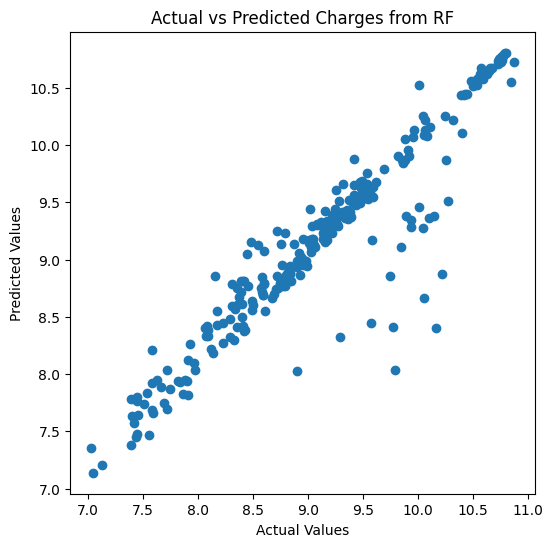

In [105]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_valid,
    preds_rf
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Charges from RF")

plt.show()

The plot above shows that the xgb model behaves worse on small charges.

## Feature Importance

In [ ]:
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

importances = rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(10)

,Feature,Importance
0,num__age,0.393851
5,cat__smoker_no,0.285019
6,cat__smoker_yes,0.170494
1,num__bmi,0.081798
2,num__children,0.038620
7,cat__region_northeast,0.008834
8,cat__region_northwest,0.004672
3,cat__sex_female,0.004559
4,cat__sex_male,0.004533
9,cat__region_southeast,0.003854


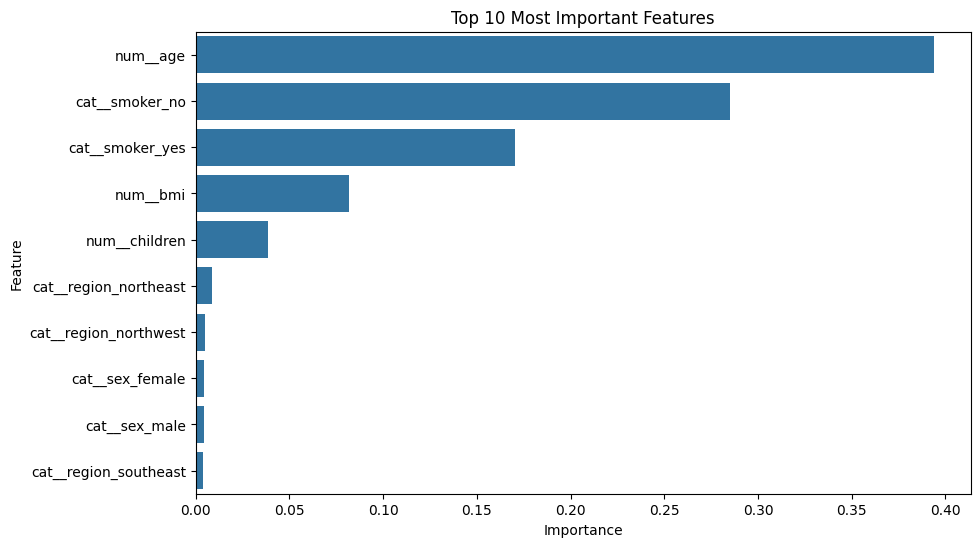

In [113]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Most Important Features')
plt.show()

Feature importance analysis showed that age and smoking status were the most influential predictors of insurance charges.

BMI also had a noticeable impact, while region and sex contributed relatively little to the model’s predictions.

This aligns with the exploratory data analysis, where smokers and older individuals tended to have significantly higher medical insurance costs.

## Cross Validation on RF
This step will show whether our model might be over- or under- fitting.

So it helps us to estimate our model across different data splits.

In [106]:
cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores.mean()

print(cv_rmse)

0.4047750551841964


Cross-validation RMSE on the log-transformed target averaged 0.3866, indicating stable model performance across folds.

## XGBRegressor

XGBRegressor (Extreme Gradient Boosting Regressor) builds an ensemble of decision trees sequentially using gradient boosting. The algorithm initializes predictions and iteratively adds new trees that predict the residuals (errors) of the previous ensemble. Each tree is trained on a gradient of the loss function, and regularization parameters (L1 and L2) penalize model complexity to prevent overfitting. XGBRegressor also employs shrinkage (learning rate) to scale each new tree's contribution, column subsampling to reduce correlation between trees, and built-in handling of missing values. The final prediction is the weighted sum of all tree outputs.



In [107]:

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
    
    ))
])
xgb_pipeline.fit(X_train, y_train)

preds_xgb = xgb_pipeline.predict(X_valid)

preds_original_xgb= np.expm1(preds_xgb)
y_valid_original = np.expm1(y_valid)

mape_xgb = mean_absolute_percentage_error(
    y_valid_original,
    preds_original_xgb
)
rmse_xgb = root_mean_squared_error(
    y_valid_original,
    preds_original_xgb
)

print(f"MAPE: {mape_xgb * 100:.2f}%")
print(f"RMSE: {rmse_xgb:.2f}")

MAPE: 16.95%
RMSE: 4044.89


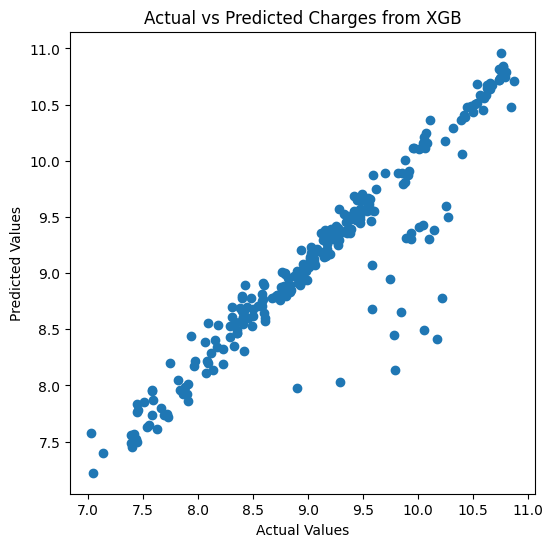

In [108]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_valid,
    preds_xgb
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Charges from XGB")

plt.show()

The plot above shows that the xgb model behaves worse on small charges (as it was in another model).

## Cross Validation on XGB
This step will show whether our model might be over- or under- fitting.

So it helps us to estimate our model across different data splits.

In [109]:
cv_scores = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores.mean()

print(cv_rmse)

0.39084300586612614


Cross-validation RMSE on the log-transformed target averaged 0.38891, indicating stable model performance across folds.

## Comparison of RandomForest and XGB regressors

XGBoost builds trees sequentially, where each new tree corrects the errors of the previous ensemble through gradient optimization. This sequential approach typically achieves higher predictive accuracy but requires careful tuning of learning rate and regularization to prevent overfitting. Random Forest, in contrast, builds all trees independently and in parallel using bootstrap sampling and random feature selection. It averages their predictions, which makes it more robust to overfitting with default parameters and faster to train, though often at the cost of lower accuracy compared to a well-tuned XGBoost model.

In [110]:
results = pd.DataFrame({
    "Model": [
        "XGB Regression",
        "Random Forest Regression"
        ],
    "RMSE": [
        rmse_xgb,
        rmse_rf],
    "MAPE (%)": [
        mape_xgb*100,
        mape_rf*100],  
    
})

results

,Model,RMSE,MAPE (%)
0,XGB Regression,4044.890627,16.951835
1,Random Forest Regression,3964.227453,18.402261


The performance comparison between the two models shows that both algorithms achieved similar predictive performance, with each model performing better on different evaluation metrics.

Random Forest Regression achieved a lower RMSE value of approximately 3964, compared to 4045 for XGB Regression. This indicates that the Random Forest model produced predictions slightly closer to the actual insurance charges on average.

On the other hand, XGB Regression achieved a lower MAPE score of 16.95%, while the Random Forest model obtained 18.40%. This means that XGB Regression had a smaller average percentage error when predicting insurance costs.

Overall, both models demonstrated solid predictive performance on the dataset. Random Forest Regression performed slightly better in terms of RMSE, while XGB Regression achieved better percentage-based accuracy according to the MAPE metric.


## Conclusion

The objective of this project was to analyze the factors influencing medical insurance charges and develop machine learning models capable of predicting insurance costs based on patient characteristics.

During the exploratory data analysis, several important relationships were identified. Smoking status had the strongest impact on insurance charges, while age and BMI also showed positive correlations with medical costs. Since the target variable (`charges`) was highly skewed, a logarithmic transformation was applied to improve the distribution and enhance model performance.

Two machine learning models were trained and evaluated: Random Forest Regression and XGB Regression. Model performance was assessed using RMSE and MAPE metrics on the validation dataset.

The results showed that both models achieved solid predictive performance:
- Random Forest Regression achieved the lowest RMSE value of 3964.23
- XGB Regression achieved the lowest MAPE value of 16.95%

These results indicate that both models were effective at predicting insurance charges, with Random Forest producing slightly more stable predictions overall, while XGB Regression demonstrated better percentage-based prediction accuracy.

Overall, this project demonstrated the complete machine learning workflow, including data preprocessing, exploratory data analysis, feature encoding, model training, cross-validation, and model evaluation. The final results highlight the importance of lifestyle-related factors, especially smoking status, in determining medical insurance costs.